In [1]:
import os
import re
import glob
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr

In [2]:
INPUT = "/kaggle/input/datasets/nocturnalnerd18"
OUT_DIR = "/kaggle/working/atp_llava_analysis"
os.makedirs(OUT_DIR, exist_ok=True)

N_LAYER, N_HEAD = 32, 32
N_COMP = N_LAYER * N_HEAD + N_LAYER
GROUPS = ["visual", "text", "tail"]

MIN_GROUP = 10
MIN_BIN = 5
N_BINS = 8
N_PERM = 500
K_TOP = 20
MIN_LOGITS = 0.05
DRIVEN_TE = -1.0
SHORT_N = 60

CONTRASTS = {
    "flip": ("false_yes", "true_no", 1, None),
    "evidence": ("false_yes", "true_yes", 1, None),
    "evidence_matched": ("false_yes", "true_yes", N_BINS, None),
    "matched_driven": ("false_yes", "true_yes", N_BINS, "driven"),
    "matched_prior": ("false_yes", "true_yes", N_BINS, "prior"),
}
GROUP_CONTRASTS = ["evidence_matched", "matched_driven"]
UNITS = {
    "attribute": ("attribute", None),
    "object": ("object", None),
    "relation/reefknot": ("relation", "reefknot"),
    "relation/amber": ("relation", "amber"),
}
PLOT_UNITS = ["attribute", "object", "relation/reefknot"]


def batch_number(path):
    return int(re.search(r"_batch_(\d+)\.pt$", path).group(1))


entries = []
for path in sorted(glob.glob(f"{INPUT}/atp-llava-noising/*_batch_*.pt"), key=lambda p: (os.path.basename(p).split("_batch_")[0], batch_number(p))):
    entries.extend(torch.load(path))
assert len(entries) == 8403 and all(e["ok"] for e in entries), "attach atp-llava-noising with all 8403 entries ok"

df = pd.DataFrame([{
    "question_id": e["question_id"], "hallucination_type": e["hallucination_type"], "source": e["source"], "split": e["split"],
    "stratum": e["stratum"], "sign": e["sign"], "delta_clean": e["delta_clean"], "delta_corrupt": e["delta_corrupt"], "TE": e["TE"],
} for e in entries])
df["row"] = np.arange(len(df))
df["gap_clean"] = df.sign * df.delta_clean
df["gap_corrupt"] = df.sign * df.delta_corrupt
df["te_cls"] = np.where(df.stratum.eq("false_yes"), np.where(df.TE < DRIVEN_TE, "driven", "prior"), "none")

sign = df.sign.to_numpy(dtype=np.float32)
head = torch.stack([e["head"] for e in entries]).numpy()
mlp = torch.stack([e["mlp"] for e in entries]).numpy()
effect = np.concatenate([head.reshape(len(df), 3, -1), mlp], axis=2)
FEATURES_GROUP = (-sign[:, None, None] * effect).astype(np.float32)
FEATURES = FEATURES_GROUP.sum(1)
FEATURES_GROUP_FLAT = FEATURES_GROUP.reshape(len(df), -1)
assert np.isfinite(FEATURES_GROUP_FLAT).all()
print(len(df), "questions,", FEATURES.shape[1], "components,", FEATURES_GROUP_FLAT.shape[1], "component by position group features")

print("--- sanity: blind-run Yes minus No gap and clean gap per stratum ---")
print(df.groupby("stratum")[["gap_clean", "gap_corrupt", "TE"]].mean().round(3))
print("--- false_yes split by total effect ---")
print(pd.crosstab([df.hallucination_type, df.source, df.split], [df.stratum, df.te_cls]))

8403 questions, 1056 components, 3168 component by position group features
--- sanity: blind-run Yes minus No gap and clean gap per stratum ---
           gap_clean  gap_corrupt     TE
stratum                                 
false_yes      1.287        0.618 -0.669
true_no       -1.303        0.516  1.819
true_yes       2.118        0.593  1.524
--- false_yes split by total effect ---
stratum                           false_yes       true_no true_yes
te_cls                               driven prior    none     none
hallucination_type source   split                                 
attribute          amber    test        107   155     153      235
                            train       558   649     735     1091
                            val         112   155     153      236
object             pope     test         11    16      18       27
                            train        45    90      84      126
                            val           9    23      18       27
relation

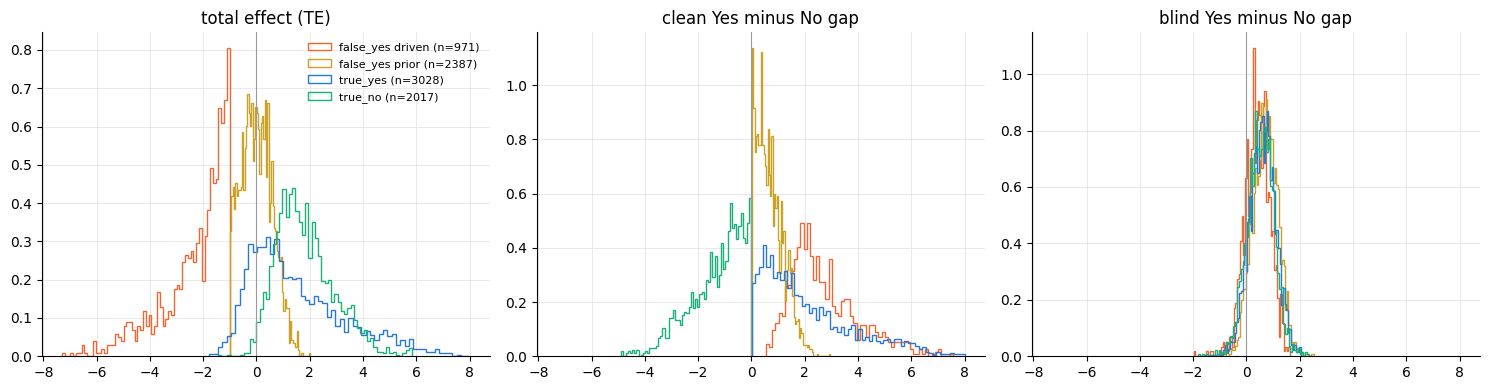

In [3]:
def unit_mask(unit):
    t, source = UNITS[unit]
    mask = df.hallucination_type.eq(t)
    if source is not None:
        mask &= df.source.eq(source)
    return mask


def count_rows(unit, stratum, splits, a_filter=None):
    mask = unit_mask(unit) & df.stratum.eq(stratum) & df.split.isin(splits)
    if a_filter is not None:
        mask &= df.te_cls.eq(a_filter)
    return int(mask.sum())


def comp_name(i, grouped=False):
    group = ""
    if grouped:
        group, i = f"{GROUPS[i // N_COMP]} ", i % N_COMP
    if i < N_LAYER * N_HEAD:
        return f"{group}L{i // N_HEAD} H{i % N_HEAD}"
    return f"{group}L{i - N_LAYER * N_HEAD} MLP"


GROUP_COLORS = {"false_yes driven": "#eb6834", "false_yes prior": "#c9a227", "true_yes": "#2a78d6", "true_no": "#1baf7a"}
UNIT_COLORS = {"attribute": "#2a78d6", "object": "#eb6834", "relation/reefknot": "#1baf7a"}
layer_axis = np.arange(N_LAYER)
df["class"] = np.where(df.stratum.eq("false_yes"), "false_yes " + df.te_cls, df.stratum)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for ax, (name, sel) in zip(axes, [("total effect (TE)", "TE"), ("clean Yes minus No gap", "gap_clean"), ("blind Yes minus No gap", "gap_corrupt")]):
    for cls, color in GROUP_COLORS.items():
        x = df[df["class"].eq(cls)][sel]
        if len(x):
            ax.hist(x.clip(-8, 8), bins=60, histtype="step", color=color, lw=1.6, density=True, label=f"{cls} (n={len(x)})")
    ax.axvline(0, color="#999999", lw=0.8)
    ax.set_title(name)
    ax.grid(color="#e5e5e2", lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/te_distribution.png", dpi=150)
plt.show()

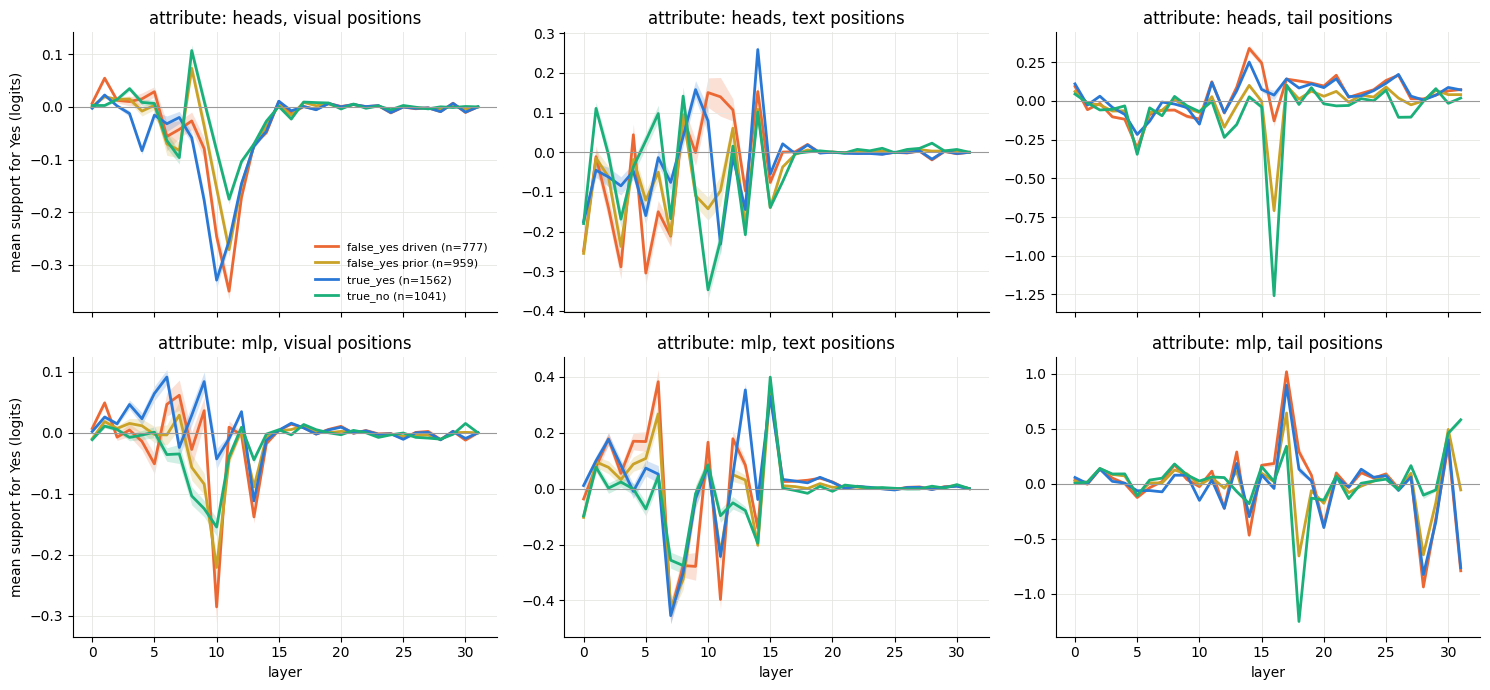

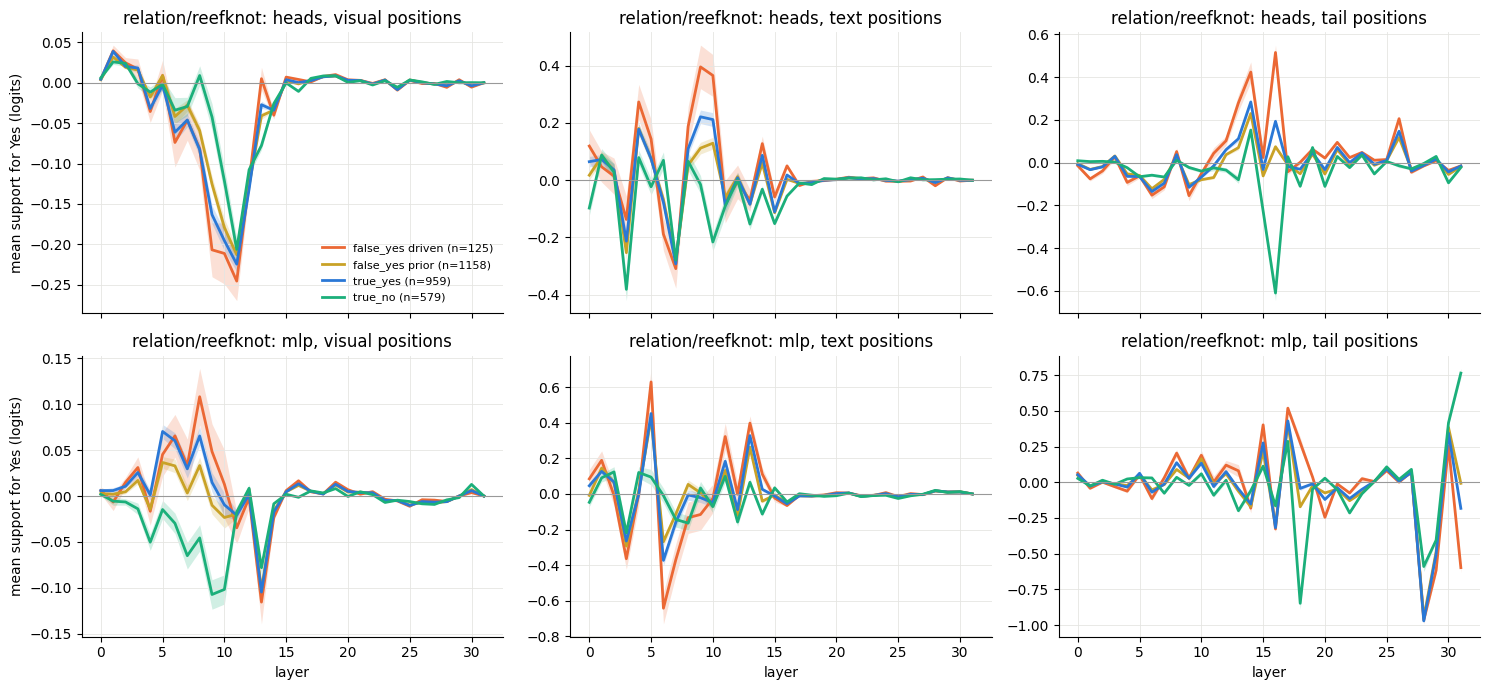

In [4]:
def layer_profile(class_name, unit, g, kind):
    rows = df[unit_mask(unit) & df["class"].eq(class_name)].row.to_numpy()
    block = FEATURES_GROUP[rows][:, g]
    if kind == "heads":
        return block[:, :N_LAYER * N_HEAD].reshape(-1, N_LAYER, N_HEAD).sum(2)
    return block[:, N_LAYER * N_HEAD:]


for unit in ["attribute", "relation/reefknot"]:
    fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
    for col, g in enumerate(range(3)):
        for row, kind in enumerate(["heads", "mlp"]):
            ax = axes[row, col]
            for cls, color in GROUP_COLORS.items():
                x = layer_profile(cls, unit, g, kind)
                if len(x) < 2:
                    continue
                m, se = x.mean(0), x.std(0, ddof=1) / np.sqrt(len(x))
                ax.plot(layer_axis, m, color=color, lw=2, label=f"{cls} (n={len(x)})")
                ax.fill_between(layer_axis, m - 1.96 * se, m + 1.96 * se, color=color, alpha=0.2, lw=0)
            ax.axhline(0, color="#999999", lw=0.8)
            ax.set_title(f"{unit}: {kind}, {GROUPS[g]} positions")
            ax.grid(color="#e5e5e2", lw=0.6)
            ax.spines[["top", "right"]].set_visible(False)
            if col == 0:
                ax.set_ylabel("mean support for Yes (logits)")
            if row == 1:
                ax.set_xlabel("layer")
    axes[0, 0].legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/layer_profiles_{unit.replace('/', '_')}.png", dpi=150)
    plt.show()

In [5]:
def build_strata(unit, g_a, g_b, splits, n_bins, a_filter, F):
    keep = unit_mask(unit) & df.stratum.isin([g_a, g_b]) & df.split.isin(splits)
    if a_filter is not None:
        keep &= df.stratum.ne(g_a) | df.te_cls.eq(a_filter)
    sub_all = df[keep]
    strata = []
    for _, sub in sub_all.groupby("source"):
        if n_bins > 1:
            edges = np.quantile(sub.gap_clean, np.linspace(0, 1, n_bins + 1)[1:-1])
            parts = [p for _, p in sub.groupby(np.digitize(sub.gap_clean, edges))]
            min_group = MIN_BIN
        else:
            parts, min_group = [sub], MIN_GROUP
        for part in parts:
            is_a = part.stratum.eq(g_a).to_numpy()
            if is_a.sum() < min_group or (~is_a).sum() < min_group:
                continue
            X = F[part.row.to_numpy()].astype(np.float64)
            strata.append((X, X ** 2, is_a))
    return strata


def effects(strata, masks):
    n_comp = strata[0][0].shape[1]
    d_sum, m_sum, w_sum = np.zeros(n_comp), np.zeros(n_comp), 0.0
    for (X, X2, _), mask in zip(strata, masks):
        na, nb = mask.sum(), (~mask).sum()
        mf = mask.astype(np.float64)
        sa, sa2 = mf @ X, mf @ X2
        sb, sb2 = X.sum(0) - sa, X2.sum(0) - sa2
        ma, mb = sa / na, sb / nb
        va, vb = (sa2 - na * ma ** 2) / (na - 1), (sb2 - nb * mb ** 2) / (nb - 1)
        sp = np.sqrt(np.maximum(((na - 1) * va + (nb - 1) * vb) / (na + nb - 2), 0))
        w = na * nb / (na + nb)
        d_sum += w * (ma - mb) / np.maximum(sp, 1e-6)
        m_sum += w * (ma - mb)
        w_sum += w
    return d_sum / w_sum, m_sum / w_sum


def perm_null(strata, seed=0):
    rng = np.random.default_rng(seed)
    null = np.empty(N_PERM)
    for b in range(N_PERM):
        d, _ = effects(strata, [rng.permutation(mask) for _, _, mask in strata])
        null[b] = np.abs(d).max()
    return null


def run_contrast(unit, cname, F):
    g_a, g_b, n_bins, a_filter = CONTRASTS[cname]
    train = build_strata(unit, g_a, g_b, ["train"], n_bins, a_filter, F)
    val = build_strata(unit, g_a, g_b, ["val"], n_bins, a_filter, F)
    test = build_strata(unit, g_a, g_b, ["test"], n_bins, a_filter, F)
    if not train or not val or not test:
        return None
    d_train, m_train = effects(train, [m for _, _, m in train])
    d_val, m_val = effects(val, [m for _, _, m in val])
    d_test, m_test = effects(test, [m for _, _, m in test])
    null95 = float(np.quantile(perm_null(train), 0.95))
    material = (np.abs(d_train) > null95) & (np.sign(m_train) == np.sign(m_val)) & (np.abs(m_train) >= MIN_LOGITS)
    return {
        "d_train": d_train, "m_train": m_train, "d_val": d_val, "m_val": m_val, "d_test": d_test, "m_test": m_test,
        "null95": null95, "n_a": int(sum(m.sum() for _, _, m in train)), "n_b": int(sum((~m).sum() for _, _, m in train)),
        "material": material,
    }


def report(label, r, grouped):
    sig = int((np.abs(r["d_train"]) > r["null95"]).sum())
    mat = r["material"]
    agree = float((np.sign(r["m_train"][mat]) == np.sign(r["m_test"][mat])).mean()) if mat.any() else float("nan")
    print(f"{label:45s} {r['n_a']}/{r['n_b']} train | residual logit gap {r['m_train'].sum():+.3f} | null95 {r['null95']:.3f} | "
          f"significant {sig} | material {int(mat.sum())} | test sign agreement {agree:.2f}")

In [6]:
results = {}
for unit in UNITS:
    for cname in CONTRASTS:
        r = run_contrast(unit, cname, FEATURES)
        if r is None:
            print(f"{unit:18s} {cname:17s} not enough examples, skipped")
            continue
        results[(unit, cname)] = r
        report(f"{unit} / {cname}", r, False)

attribute / flip                              1207/735 train | residual logit gap +1.958 | null95 0.191 | significant 700 | material 77 | test sign agreement 1.00
attribute / evidence                          1207/1091 train | residual logit gap -1.461 | null95 0.169 | significant 612 | material 64 | test sign agreement 1.00
attribute / evidence_matched                  1207/1091 train | residual logit gap -0.118 | null95 0.179 | significant 485 | material 50 | test sign agreement 1.00
attribute / matched_driven                    558/1091 train | residual logit gap +0.005 | null95 0.215 | significant 442 | material 58 | test sign agreement 0.98
attribute / matched_prior                     644/439 train | residual logit gap -0.136 | null95 0.270 | significant 335 | material 32 | test sign agreement 1.00
object / flip                                 135/84 train | residual logit gap +3.406 | null95 0.575 | significant 450 | material 82 | test sign agreement 1.00
object / evidence      

In [7]:
results_group = {}
for unit in UNITS:
    for cname in GROUP_CONTRASTS:
        r = run_contrast(unit, cname, FEATURES_GROUP_FLAT)
        if r is None:
            print(f"{unit:18s} {cname:17s} not enough examples, skipped")
            continue
        results_group[(unit, cname)] = r
        report(f"{unit} / {cname} by position group", r, True)
        mat = np.flatnonzero(r["material"])
        share = {GROUPS[g]: int(((mat // N_COMP) == g).sum()) for g in range(3)}
        print(f"{'':45s} material components by position group: {share}")

attribute / evidence_matched by position group 1207/1091 train | residual logit gap -0.118 | null95 0.195 | significant 1253 | material 44 | test sign agreement 1.00
                                              material components by position group: {'visual': 8, 'text': 24, 'tail': 12}
attribute / matched_driven by position group  558/1091 train | residual logit gap +0.005 | null95 0.233 | significant 1129 | material 52 | test sign agreement 0.98
                                              material components by position group: {'visual': 7, 'text': 29, 'tail': 16}
object             evidence_matched  not enough examples, skipped
object             matched_driven    not enough examples, skipped
relation/reefknot / evidence_matched by position group 901/671 train | residual logit gap -0.190 | null95 0.228 | significant 10 | material 0 | test sign agreement nan
                                              material components by position group: {'visual': 0, 'text': 0, 'tail': 0}
rel

In [8]:
for (unit, cname), r in results.items():
    if cname == "flip":
        continue
    top = np.argsort(-np.abs(r["m_train"]))[:K_TOP]
    print(f"--- {unit} / {cname}: {r['n_a']} vs {r['n_b']} train questions, mean logit gap {r['m_train'].sum():+.3f} ---")
    print(f"material components: {int(r['material'].sum())} | top-{K_TOP} by logits net {r['m_train'][top].sum():+.3f} of the gap")
    table = pd.DataFrame({
        "component": [comp_name(i) for i in top[:10]],
        "logits_train": r["m_train"][top[:10]].round(3),
        "logits_val": r["m_val"][top[:10]].round(3),
        "logits_test": r["m_test"][top[:10]].round(3),
        "d_train": r["d_train"][top[:10]].round(2),
        "material": r["material"][top[:10]],
    })
    print(table.to_string(index=False))

--- attribute / evidence: 1207 vs 1091 train questions, mean logit gap -1.461 ---
material components: 64 | top-20 by logits net -0.556 of the gap
component  logits_train  logits_val  logits_test  d_train  material
  L31 MLP         0.371       0.383        0.397     0.67      True
  L18 MLP        -0.364      -0.329       -0.438    -0.49      True
  L13 MLP        -0.284      -0.308       -0.313    -0.55      True
  L16 H15        -0.263      -0.265       -0.279    -0.94      True
   L6 MLP         0.259       0.241        0.187     0.40      True
  L14 MLP        -0.197      -0.216       -0.202    -0.56      True
   L9 MLP        -0.194      -0.299       -0.322    -0.24      True
   L7 MLP         0.179       0.214        0.119     0.28      True
   L16 H0        -0.169      -0.126       -0.177    -0.56      True
   L4 MLP         0.144       0.158        0.145     0.28      True
--- attribute / evidence_matched: 1207 vs 1091 train questions, mean logit gap -0.118 ---
material compon

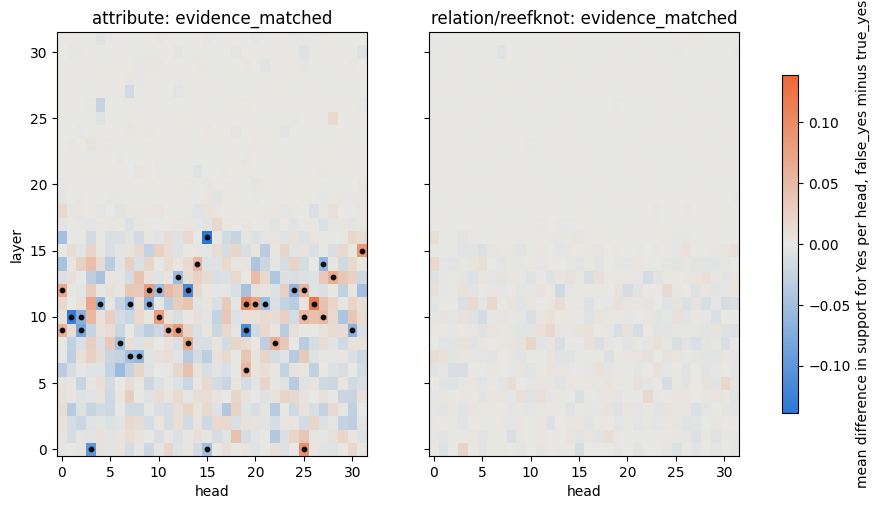

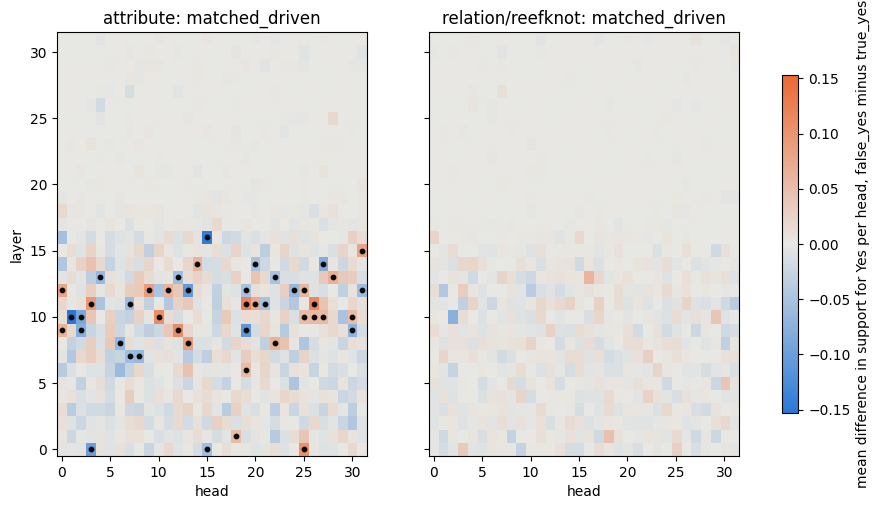

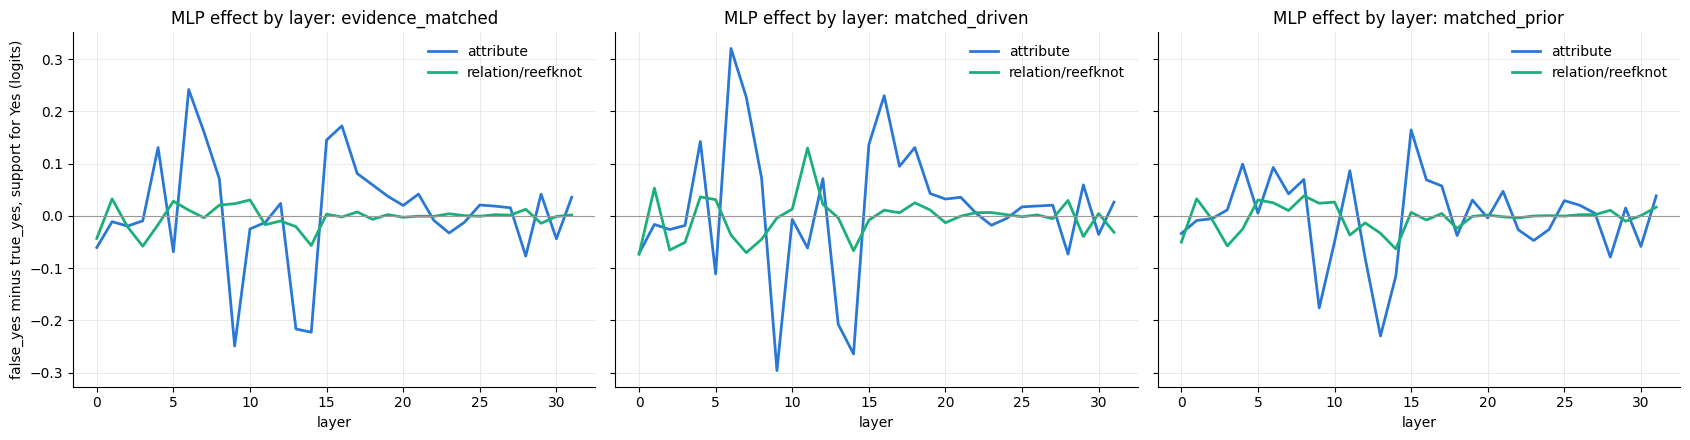

In [9]:
DIVERGING = LinearSegmentedColormap.from_list("atp_div", ["#2a78d6", "#e8e8e4", "#eb6834"])
for cname in ["evidence_matched", "matched_driven"]:
    plot_units = [u for u in PLOT_UNITS if (u, cname) in results]
    if not plot_units:
        continue
    head_m = {u: results[(u, cname)]["m_train"][:N_LAYER * N_HEAD] for u in plot_units}
    limit = max(np.abs(v).max() for v in head_m.values())
    fig, axes = plt.subplots(1, len(plot_units), figsize=(5.5 * len(plot_units), 5.5), sharey=True, squeeze=False)
    for ax, unit in zip(axes[0], plot_units):
        im = ax.imshow(head_m[unit].reshape(N_LAYER, N_HEAD), origin="lower", cmap=DIVERGING, vmin=-limit, vmax=limit, aspect="auto")
        ys, xs = np.nonzero(results[(unit, cname)]["material"][:N_LAYER * N_HEAD].reshape(N_LAYER, N_HEAD))
        ax.scatter(xs, ys, s=10, color="#0b0b0b")
        ax.set_title(f"{unit}: {cname}")
        ax.set_xlabel("head")
    axes[0, 0].set_ylabel("layer")
    fig.colorbar(im, ax=axes.ravel().tolist(), label="mean difference in support for Yes per head, false_yes minus true_yes", shrink=0.8)
    plt.savefig(f"{OUT_DIR}/head_effects_{cname}.png", dpi=150, bbox_inches="tight")
    plt.show()

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharey=True)
for ax, cname in zip(axes, ["evidence_matched", "matched_driven", "matched_prior"]):
    for unit in PLOT_UNITS:
        if (unit, cname) not in results:
            continue
        r = results[(unit, cname)]
        ax.plot(layer_axis, r["m_train"][N_LAYER * N_HEAD:], color=UNIT_COLORS[unit], lw=2, label=unit)
    ax.axhline(0, color="#999999", lw=0.8)
    ax.set_title(f"MLP effect by layer: {cname}")
    ax.set_xlabel("layer")
    ax.grid(color="#e5e5e2", lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False)
axes[0].set_ylabel("false_yes minus true_yes, support for Yes (logits)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/mlp_effects.png", dpi=150)
plt.show()

In [10]:
dla_path = f"{INPUT}/dla-llava-analysis/effects.json"
assert os.path.exists(dla_path), "attach dla-llava-analysis version 2"
with open(dla_path) as f:
    dla_effects = json.load(f)

for unit in PLOT_UNITS:
    for cname in ["evidence_matched"]:
        key = f"{unit}/{cname}"
        if key not in dla_effects or (unit, cname) not in results:
            continue
        atp_m = results[(unit, cname)]["m_train"]
        dla_m = np.array(dla_effects[key]["m_train"])[:N_COMP]
        top_atp, top_dla = set(np.argsort(-np.abs(atp_m))[:K_TOP]), set(np.argsort(-np.abs(dla_m))[:K_TOP])
        print(f"--- {key}: attribution patching vs DLA over {N_COMP} components ---")
        print(f"spearman of signed effects {spearmanr(atp_m, dla_m)[0]:.3f} | spearman of magnitudes {spearmanr(np.abs(atp_m), np.abs(dla_m))[0]:.3f} | "
              f"top-{K_TOP} overlap {len(top_atp & top_dla)} (chance {K_TOP * K_TOP / N_COMP:.1f})")
        order = np.argsort(-np.abs(atp_m))[:15]
        table = pd.DataFrame({
            "component": [comp_name(i) for i in order], "atp_logits": atp_m[order].round(3), "dla_logits": dla_m[order].round(3),
            "atp_material": results[(unit, cname)]["material"][order],
            "dla_material": [int(i) in set(dla_effects[key]["material"]) for i in order],
        })
        print(table.to_string(index=False))
        carriers = [i for i in np.argsort(-np.abs(atp_m))[:K_TOP] if abs(dla_m[i]) < MIN_LOGITS]
        print(f"top-{K_TOP} attribution patching components with negligible DLA (indirect carriers): {[comp_name(i) for i in carriers]}")

--- attribute/evidence_matched: attribution patching vs DLA over 1056 components ---
spearman of signed effects 0.049 | spearman of magnitudes 0.113 | top-20 overlap 5 (chance 0.4)
component  atp_logits  dla_logits  atp_material  dla_material
   L9 MLP      -0.249       0.003          True         False
   L6 MLP       0.242       0.001          True         False
  L14 MLP      -0.223      -0.021          True         False
  L13 MLP      -0.216       0.011          True         False
  L16 MLP       0.172      -0.022          True         False
   L7 MLP       0.160      -0.001          True         False
  L15 MLP       0.145       0.034          True         False
  L16 H15      -0.139       0.005          True         False
   L4 MLP       0.131      -0.001          True         False
   L10 H1      -0.131       0.001          True         False
  L11 H26       0.119      -0.000          True         False
  L12 H13      -0.116      -0.000          True         False
   L9 H19    

In [11]:
shortlist = {"ranked": [], "always_include": []}
scores = {}
for (unit, cname), r in list(results.items()) + list(results_group.items()):
    if cname not in GROUP_CONTRASTS:
        continue
    grouped = r["m_train"].shape[0] > N_COMP
    for i in np.flatnonzero(r["material"]):
        base = int(i % N_COMP)
        entry = scores.setdefault(base, {"score": 0.0, "evidence": {}})
        entry["score"] = max(entry["score"], float(abs(r["m_train"][i])))
        key = f"{unit}/{cname}" + (f"/{GROUPS[i // N_COMP]}" if grouped else "")
        entry["evidence"][key] = float(r["m_train"][i])

for base in sorted(scores, key=lambda b: -scores[b]["score"])[:SHORT_N]:
    shortlist["ranked"].append({"component": comp_name(base), "index": base, "score": scores[base]["score"], "evidence": scores[base]["evidence"]})

shortlist["always_include"] = (
    [{"component": f"L{l} MLP", "index": N_LAYER * N_HEAD + l, "group": "all"} for l in range(N_LAYER)]
    + [{"component": f"L{l} MLP", "index": N_LAYER * N_HEAD + l, "group": "visual"} for l in range(N_LAYER)]
)
print(len(scores), "components are material in at least one evidence contrast;", len(shortlist["ranked"]), "shortlisted")
print(pd.DataFrame(shortlist["ranked"][:25])[["component", "index", "score"]].to_string(index=False))

with open(f"{OUT_DIR}/shortlist.json", "w") as f:
    json.dump(shortlist, f)

with open(f"{OUT_DIR}/effects.json", "w") as f:
    json.dump({
        **{
            f"{unit}/{cname}": {
                "d_train": r["d_train"].tolist(), "d_val": r["d_val"].tolist(), "d_test": r["d_test"].tolist(),
                "m_train": r["m_train"].tolist(), "m_val": r["m_val"].tolist(), "m_test": r["m_test"].tolist(),
                "material": np.flatnonzero(r["material"]).tolist(), "null95": r["null95"], "n_a": r["n_a"], "n_b": r["n_b"],
            }
            for (unit, cname), r in results.items()
        },
        **{
            f"{unit}/{cname}/by_group": {
                "d_train": r["d_train"].tolist(), "d_val": r["d_val"].tolist(), "d_test": r["d_test"].tolist(),
                "m_train": r["m_train"].tolist(), "m_val": r["m_val"].tolist(), "m_test": r["m_test"].tolist(),
                "material": np.flatnonzero(r["material"]).tolist(), "null95": r["null95"], "n_a": r["n_a"], "n_b": r["n_b"],
            }
            for (unit, cname), r in results_group.items()
        },
    }, f)

71 components are material in at least one evidence contrast; 60 shortlisted
component  index    score
   L6 MLP   1030 0.323983
   L9 MLP   1033 0.296012
  L13 MLP   1037 0.266237
  L14 MLP   1038 0.264096
  L16 MLP   1040 0.239335
  L10 MLP   1034 0.236024
   L7 MLP   1031 0.226871
   L4 MLP   1028 0.184381
  L11 H26    378 0.159472
   L10 H1    321 0.153390
  L11 MLP   1035 0.150489
  L16 H15    527 0.148401
  L15 MLP   1039 0.145089
    L0 H3      3 0.139184
  L18 MLP   1042 0.130612
  L12 H13    397 0.126886
   L5 MLP   1029 0.121879
  L11 H19    371 0.118385
   L0 H25     25 0.115959
   L9 H19    307 0.113081
   L9 H12    300 0.108504
   L10 H2    322 0.107634
  L10 H10    330 0.106929
   L8 MLP   1032 0.099015
  L17 MLP   1041 0.095700


In [12]:
USERNAME = "nocturnalnerd18"

with open(os.path.join(OUT_DIR, "dataset-metadata.json"), "w") as f:
    json.dump({
        "title": "atp-llava-analysis",
        "id": f"{USERNAME}/atp-llava-analysis",
        "subtitle": "Attribution patching effect sizes and shortlisted components for LLaVA",
        "description": "Per-component noising attribution patching effects for every attention head and MLP layer, in logits of support for Yes "
                       "(minus sign times the first-order change in the sign-corrected Yes minus No gap when the component is replaced by its corrupt activation). "
                       "Contrasts: flip (false_yes vs true_no), evidence (false_yes vs true_yes), evidence_matched (within bins of the clean gap), "
                       "matched_driven (false_yes with total effect below -1, the image pushed Yes beyond the blind prior) and matched_prior (the rest). "
                       "Units are attribute, object, relation/reefknot and relation/amber. m_* vectors are mean logit gaps and d_* vectors Cohen's d, ranked on train, "
                       "checked on val and reported on test. Components are indexed as layer * 32 + head for heads and 1024 + layer for MLPs; the by_group entries use "
                       "group * 1056 + component with groups visual, text, tail. shortlist.json holds the ranked material components for exact activation patching plus "
                       "every layer MLP at all and at visual positions, which attribution patching handles worst.",
        "licenses": [{"name": "CC0-1.0"}],
    }, f)

!kaggle datasets create -p {OUT_DIR}

Starting upload for file head_effects_evidence_matched.png
100%|███████████████████████████████████████| 64.9k/64.9k [00:00<00:00, 261kB/s]
Upload successful: head_effects_evidence_matched.png (65KB)
Starting upload for file mlp_effects.png
100%|█████████████████████████████████████████| 174k/174k [00:00<00:00, 800kB/s]
Upload successful: mlp_effects.png (174KB)
Starting upload for file layer_profiles_relation_reefknot.png
100%|████████████████████████████████████████| 409k/409k [00:00<00:00, 1.63MB/s]
Upload successful: layer_profiles_relation_reefknot.png (409KB)
Starting upload for file effects.json
100%|██████████████████████████████████████| 3.46M/3.46M [00:00<00:00, 10.8MB/s]
Upload successful: effects.json (3MB)
Starting upload for file te_distribution.png
100%|███████████████████████████████████████| 84.2k/84.2k [00:00<00:00, 380kB/s]
Upload successful: te_distribution.png (84KB)
Starting upload for file shortlist.json
100%|██████████████████████████████████████| 18.3k/18.3k [0